### 0. Importing

In [13]:
#%pip install seaborn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
data = pd.read_csv('PartI_dev.csv')
print(data.Y.value_counts()) # We have 11 classes 
print(data.shape)

# =====================================================================
# Ideally need a multiclass classification model. \
# Start with Multiclass Logistic Regression, then try Random Forest, then try XGBoost??
#
# Pipeline:
# 1. Standardize the data / Encode categorical variables if necessary
# 2. PCA to reduce dimensionality and remove multicollinearity
# 3. Cross-validation to find the best hyperparameters for the model
# 4. Train a Multiclass Logistic Regression model
# 5. Evaluate the model using mean squared error, R^2 score, and other performance metrics.
# 6. Repeat steps 3-5 with Random Forest and XGBoost models, and compare the results.
# =====================================================================

Y
1     4255
2     4255
3     4255
4     4255
5     4255
6     4255
7     4255
8     4255
9     4255
10    4255
11    4255
Name: count, dtype: int64
(46805, 49)


### 1. Data Inspections

<Axes: >

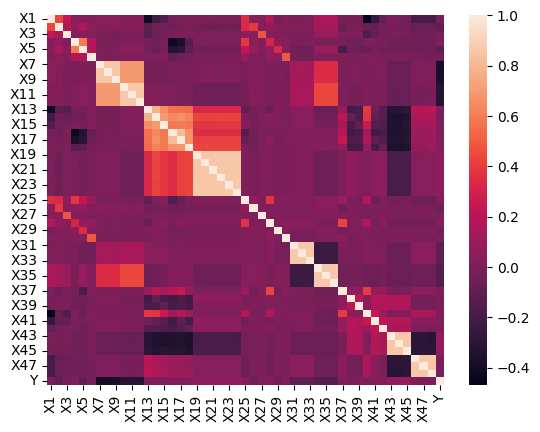

In [ ]:
sns.heatmap(data.corr())
# Based on the heatmap, we can see that there are some features that have
# high correlation with one another, we will need to worry about multicollinearity when we build our model. 
# We can also see that there are some features that have low correlation with the target variable, 
# we may want to consider dropping those features when we build our model.

# PCA will be needed. Now we can use regularization but it will not be as effective as PCA.
# Due to the nature of the correlation matrix, we will need to use PCA

<Axes: >

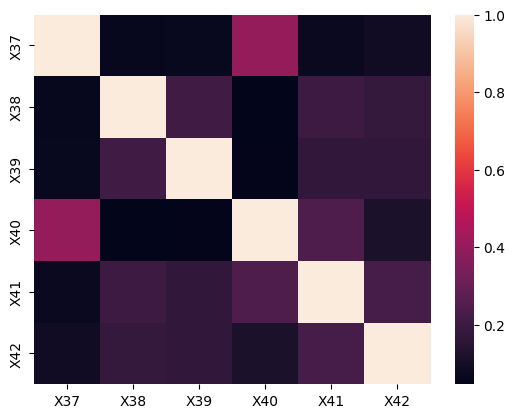

In [9]:
sns.heatmap(data[['X37', 'X38', 'X39', 'X40', 'X41', 'X42']].corr())

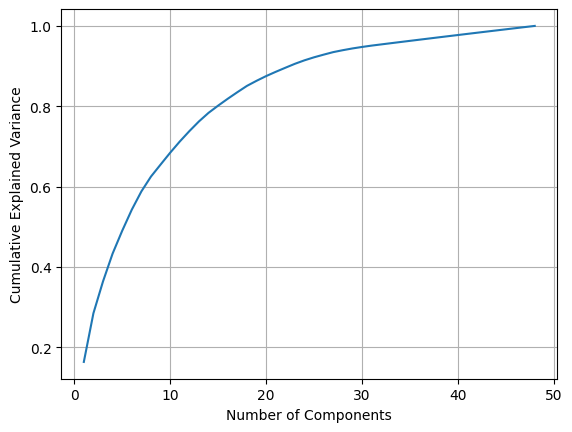

Number of components for 95% variance: 31


In [8]:
# =====================================================================
# Scree Plot to determine how many components to use in PCA when building our model. 
# We want to find the number of components that explain at least 95% of the variance in the data.
# =====================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['Y'])  # Drop target if present
X_scaled = StandardScaler().fit_transform(X)

pca = PCA().fit(X_scaled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
import matplotlib.pyplot as plt
plt.plot(range(1, len(explained_variance)+1), explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print(f"Number of components for 95% variance: {n_components_95}")

In [22]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components_95)),
    ('model', LogisticRegression(max_iter=1000))
])


Y = data['Y']  # Target variable
# Split your data first
X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, test_size=0.2, random_state=42)

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Evaluate on the test data
y_pred = pipeline.predict(X_test)

In [23]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6812306377523769
              precision    recall  f1-score   support

           1       0.63      0.66      0.65       851
           2       0.68      0.68      0.68       851
           3       0.63      0.64      0.64       851
           4       0.67      0.70      0.69       851
           5       0.48      0.42      0.45       851
           6       0.51      0.45      0.48       851
           7       0.96      0.96      0.96       851
           8       0.60      0.64      0.62       851
           9       0.61      0.63      0.62       851
          10       0.69      0.70      0.70       851
          11       1.00      1.00      1.00       851

    accuracy                           0.68      9361
   macro avg       0.68      0.68      0.68      9361
weighted avg       0.68      0.68      0.68      9361



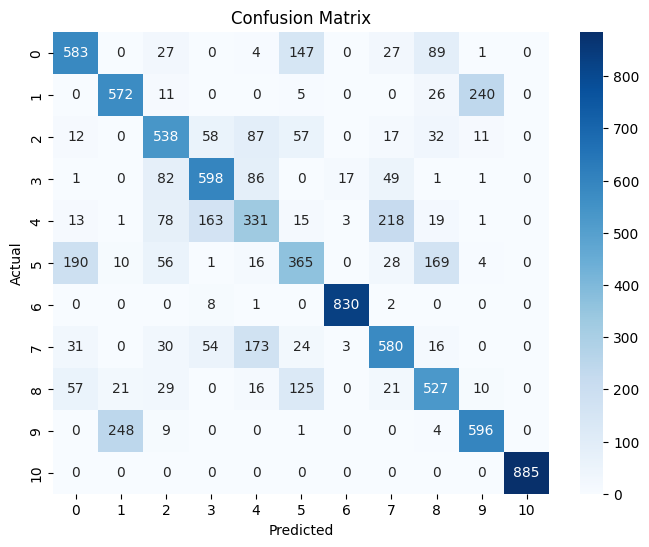

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()